In [ ]:
import numpy as np 
import modern_robotics as mr
import matplotlib.pyplot as plt

In [3]:

Slist = np.array([
    [0,  0,  1,  0,        0,       0      ],  # joint 1 (waist)
    [0,  1,  0, -0.12705,  0,       0      ],  # joint 2 (shoulder)
    [0,  1,  0, -0.42705,  0,       0.05955],  # joint 3 (elbow)
    [1,  0,  0,  0,        0.42705, 0      ],  # joint 4 (forearm roll)
    [0,  1,  0, -0.42705,  0,       0.35955],  # joint 5 (wrist angle)
    [1,  0,  0,  0,        0.42705, 0      ],  # joint 6 (wrist rotate)
]).T  # shape: (6, 6) — column i is the screw axis for joint i

# End-effector home configuration (zero joint angles)
M_HOME = np.array([
    [1, 0, 0, 0.536494],
    [0, 1, 0, 0       ],
    [0, 0, 1, 0.42705 ],
    [0, 0, 0, 1       ]
], dtype=float)


Forward Kinematics

In [4]:

import inspect

print(inspect.getsource(mr.IKinSpace))

def IKinSpace(Slist, M, T, thetalist0, eomg, ev):
    """Computes inverse kinematics in the space frame for an open chain robot

    :param Slist: The joint screw axes in the space frame when the
                  manipulator is at the home position, in the format of a
                  matrix with axes as the columns
    :param M: The home configuration of the end-effector
    :param T: The desired end-effector configuration Tsd
    :param thetalist0: An initial guess of joint angles that are close to
                       satisfying Tsd
    :param eomg: A small positive tolerance on the end-effector orientation
                 error. The returned joint angles must give an end-effector
                 orientation error less than eomg
    :param ev: A small positive tolerance on the end-effector linear position
               error. The returned joint angles must give an end-effector
               position error less than ev
    :return thetalist: Joint angles that achieve T within

# modifying IK by returning the number of iteration aswell

In [5]:
def IKinSpace_with_iters(Slist, M, T, thetalist0, eomg, ev):
    thetalist = np.array(thetalist0).copy()
    i = 0
    maxiterations = 20
    Tsb = mr.FKinSpace(M,Slist, thetalist)
    Vs = np.dot(mr.Adjoint(Tsb),mr.se3ToVec(mr.MatrixLog6(np.dot(mr.TransInv(Tsb), T))))
    err = np.linalg.norm([Vs[0], Vs[1], Vs[2]]) > eomg or np.linalg.norm([Vs[3], Vs[4], Vs[5]]) >  ev
    while err and i < maxiterations:
        thetalist = thetalist + np.dot(np.linalg.pinv(mr.JacobianSpace(Slist,thetalist)), Vs)
        i = i + 1
        Tsb = mr.FKinSpace(M, Slist, thetalist)
        Vs = np.dot(mr.Adjoint(Tsb), \
                    mr.se3ToVec(mr.MatrixLog6(np.dot(mr.TransInv(Tsb), T))))
        err = np.linalg.norm([Vs[0], Vs[1], Vs[2]]) > eomg \
              or np.linalg.norm([Vs[3], Vs[4], Vs[5]]) > ev
    return (thetalist, not err,i)

In [6]:
from ik.data.pipeline import sample_q
JOINT_LIMITS = np.deg2rad([
    [-180,  180],   # waist
    [-101,  101],   # shoulder
    [-101,   92],   # elbow
    [-180,  180],   # forearm roll
    [-107,  130],   # wrist angle
    [-180,  180],   # wrist rotate
])  # shape (6, 2)

s=sample_q(100)


# linear trajectory using Newton  raphson numerical approach

In [43]:
# for testing create a line trajectory assume no rotation
z_line = 0.6
n_points=50
p_line_start = np.array([-0.35, 0.0, z_line])
p_line_end   = np.array([ 0.35, 0.0, z_line])
p=np.linspace(p_line_start,p_line_end,50)#50 equaly spread points along the trajectory for smooth IK
Tsb = np.stack([np.identity(4)] *n_points, axis=2)
Tsb[:3,3,:]=p.transpose()#add EE position

q_init=np.zeros(6)
pos_error=[]
iter_list=[]
isconverges_list=[]
#Slist, M, T, thetalist0, eomg, ev

for idx in range(n_points):

    #print(Tsb[:,:,idx])
    q_sb,isconverges,iter = IKinSpace_with_iters(Slist, M_HOME,Tsb[:,:,idx],q_init,1e-3,1e-3)
    q_init=q_sb.copy()
    T_calc=mr.FKinBody( M_HOME,Slist,q_sb)
    err=np.linalg.norm(T_calc[:3,3]-Tsb[:3,3,idx])
    pos_error.append(err)
    iter_list.append(iter)
    isconverges_list.append(isconverges)
pos_error=np.array(pos_error)


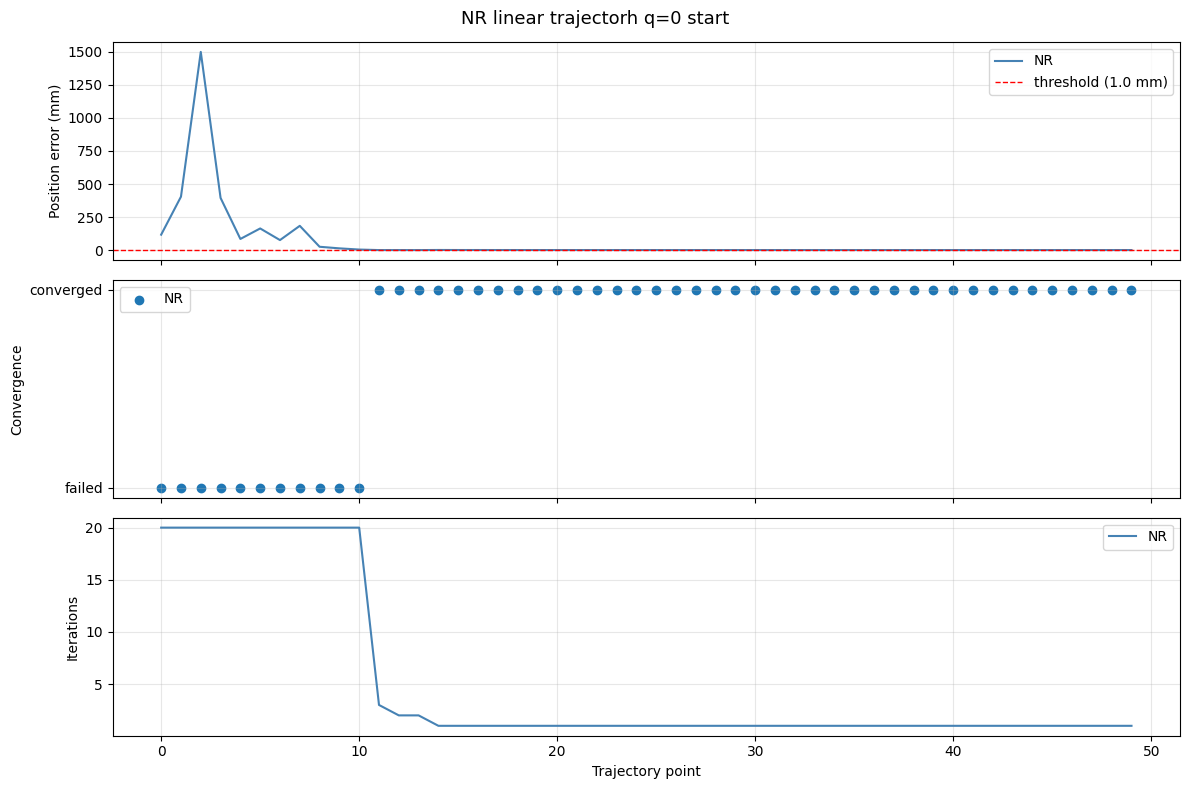

In [46]:
import matplotlib.pyplot as plt
import numpy as np

threshold_mm = 1.0  # derive convergence from error since it was discarded
x = np.arange(len(pos_error))

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# --- 1. Position error ---
axes[0].plot(x, pos_error*1000, color='steelblue', linewidth=1.5, label='NR')
axes[0].axhline(threshold_mm, color='red', linestyle='--', linewidth=1, label=f'threshold ({threshold_mm} mm)')
axes[0].set_ylabel('Position error (mm)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- 2. Converged / not converged ---
axes[1].scatter(x,isconverges_list,label='NR')
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['failed', 'converged'])
axes[1].set_ylabel('Convergence')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# --- 3. Iterations ---
axes[2].plot(x, iter_list, color='steelblue', linewidth=1.5, label='NR')

axes[2].set_ylabel('Iterations')
axes[2].set_xlabel('Trajectory point')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

fig.suptitle('NR linear trajectorh q=0 start', fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
import torch
from ik.model.mlp import MLP
DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model=MLP()
model.load_state_dict(torch.load(f'C:\Master\projects\IK\model\mlp_25326_4l256n_leakyrelu_withoutBatch.pt',map_location=DEVICE))


<>:5: SyntaxWarning: invalid escape sequence '\M'
<>:5: SyntaxWarning: invalid escape sequence '\M'
C:\Users\maxim\AppData\Local\Temp\ipykernel_32796\608642623.py:5: SyntaxWarning: invalid escape sequence '\M'
  model.load_state_dict(torch.load(f'C:\Master\projects\IK\model\mlp_25326_4l256n_leakyrelu_withoutBatch.pt',map_location=DEVICE))


<All keys matched successfully>

In [ ]:

''''
from ik.data.dataset import IKDataset
train_ds=IKDataset('train','model')
torch.save({
    'X_mean': train_ds.scaler_X[0],
    'X_std':  train_ds.scaler_X[1],
    'Y_mean': train_ds.scaler_Y[0],
    'Y_std':  train_ds.scaler_Y[1],
}, f'model/scalers.pt')
'''
